# CHƯƠNG 3 — THỰC NGHIỆM MẠNG TÍCH CHẬP (CNN)

**Bài toán:** phân loại ảnh chữ số viết tay Digits (8×8) thành 10 lớp, dùng **PyTorch**.

**Cấu trúc:** Conv(1→12) → ReLU → MaxPool → Conv(12→24) → ReLU → MaxPool → Flatten → Dense(96→48) → Dense(48→10).

**Kết quả:** theo dõi loss từng epoch, chọn epoch có Accuracy trên **validation** tốt nhất, **chỉ sau đó** kiểm tra test. Notebook này **chạy độc lập**, không cần notebook ML.

## Bước 1. Import thư viện và cài seed

`torch.nn` cung cấp tầng mạng; `DataLoader` chia dữ liệu thành batch; `matplotlib` vẽ biểu đồ.

In [1]:
from pathlib import Path
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(1)  # CPU ổn định, có thể bỏ dòng này nếu muốn
OUT = Path('ket_qua')
OUT.mkdir(exist_ok=True)
print('PyTorch version:', torch.__version__)
print('Thiết bị thực nghiệm: CPU')

PyTorch version: 2.14.0+cpu
Thiết bị thực nghiệm: CPU


## Bước 2. Tải bộ dữ liệu và chia tập giống Chương 2

Mỗi ảnh được chia cho **16** để đưa pixel về khoảng **[0,1]**. `[:, None, :, :]` tạo chiều **channel = 1**: `[số ảnh, 1, 8, 8]`.

In [2]:
digits = load_digits()
X, Y = digits.images, digits.target
indices = np.arange(len(Y))
train_idx, temp_idx = train_test_split(indices, test_size=.30, stratify=Y, random_state=SEED)
valid_idx, test_idx = train_test_split(temp_idx, test_size=.50, stratify=Y[temp_idx], random_state=SEED)

def tensors(idx):
    images = torch.tensor((X[idx]/16).astype('float32'))[:, None, :, :]
    labels = torch.tensor(Y[idx], dtype=torch.long)
    return images, labels

trX, trY = tensors(train_idx)
vaX, vaY = tensors(valid_idx)
teX, teY = tensors(test_idx)
print('Train:', trX.shape, 'Validation:', vaX.shape, 'Test:', teX.shape)

Train: torch.Size([1257, 1, 8, 8]) Validation: torch.Size([270, 1, 8, 8]) Test: torch.Size([270, 1, 8, 8])


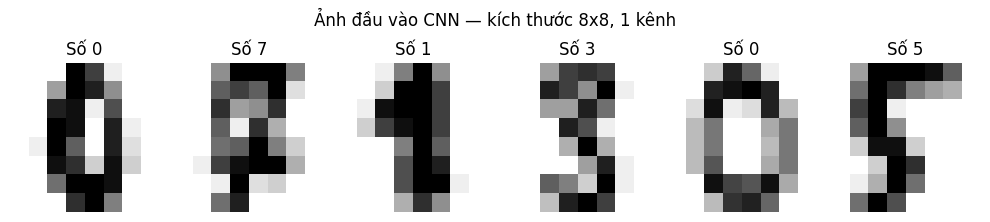

In [3]:
fig, axes = plt.subplots(1, 6, figsize=(10, 2.3))
for i, ax in enumerate(axes):
    ax.imshow(trX[i, 0], cmap='gray_r')
    ax.set_title(f'Số {int(trY[i])}')
    ax.axis('off')
fig.suptitle('Ảnh đầu vào CNN — kích thước 8x8, 1 kênh')
fig.tight_layout()
plt.show()
fig.savefig(OUT/'chuong3_du_lieu_anh.png', dpi=160)
plt.close(fig)

## Bước 3. Khai báo kiến trúc CNN

`Conv2d`: kernel 3×3 quét qua ảnh; `padding=1` giữ nguyên chiều cao/rộng. `ReLU` loại giá trị âm. `MaxPool2d(2)` giảm kích thước mỗi chiều một nửa.

**Kiểm tra kích thước:** 8×8 → pool 4×4 → pool 2×2; 24 kênh × 2 × 2 = 96 số đưa vào Dense.

In [4]:
class DigitCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 12, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(12, 24, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(24 * 2 * 2, 48),
            nn.ReLU(),
            nn.Linear(48, 10),
        )

    def forward(self, x):
        x = self.conv(x)
        return self.fc(x)  # logits, chưa đưa qua softmax

model = DigitCNN()
print(model)
print('Tổng số tham số có thể học:', sum(p.numel() for p in model.parameters()))
with torch.no_grad():
    print('Kích thước output cho 3 ảnh:', model(trX[:3]).shape)

DigitCNN(
  (conv): Sequential(
    (0): Conv2d(1, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(12, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=96, out_features=48, bias=True)
    (2): ReLU()
    (3): Linear(in_features=48, out_features=10, bias=True)
  )
)
Tổng số tham số có thể học: 7882
Kích thước output cho 3 ảnh: torch.Size([3, 10])


## Bước 4. Khai báo bộ tối ưu và DataLoader

`CrossEntropyLoss` so sánh logits với nhãn thật. `Adam` cập nhật trọng số theo gradient. `batch_size=64`: xử lý 64 ảnh/lượt; `shuffle=True`: xáo trộn **chỉ tập train**.

In [5]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.002)
criterion = nn.CrossEntropyLoss()
train_loader = DataLoader(
    TensorDataset(trX, trY), batch_size=64, shuffle=True,
    generator=torch.Generator().manual_seed(SEED)
)
print('Số batch trong một epoch:', len(train_loader))

Số batch trong một epoch: 20


## Bước 5. Huấn luyện 30 epoch và chọn mô hình tốt nhất

Mỗi batch: `zero_grad()` → `forward()` → tính `loss` → `backward()` → `optimizer.step()`.

Cuối mỗi epoch: tính Accuracy trên **validation**, lưu bản trọng số tốt nhất; test chưa được dùng. Nếu máy yếu, 30 epoch trên 1.797 ảnh nhỏ thường vẫn phù hợp.

In [6]:
best_val_accuracy = -1.0
best_epoch = 0
best_state = None
history = []

for epoch in range(1, 31):
    model.train()
    train_loss_sum = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        train_loss_sum += loss.item() * len(images)

    avg_train_loss = train_loss_sum / len(trX)
    model.eval()
    with torch.no_grad():
        val_pred = model(vaX).argmax(dim=1).numpy()
    val_accuracy = accuracy_score(Y[valid_idx], val_pred)
    history.append({'Epoch': epoch, 'Train Loss': avg_train_loss, 'Valid Accuracy': val_accuracy})

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = float(val_accuracy)
        best_epoch = epoch
        best_state = {key: value.detach().clone() for key, value in model.state_dict().items()}

    if epoch == 1 or epoch % 5 == 0:
        print(f'Epoch {epoch:02d} | Train loss={avg_train_loss:.4f} | Valid accuracy={val_accuracy:.4f}')

model.load_state_dict(best_state)
print('Chọn epoch:', best_epoch, '| Validation Accuracy tốt nhất:', round(best_val_accuracy, 4))

Epoch 01 | Train loss=2.2758 | Valid accuracy=0.1259
Epoch 05 | Train loss=0.4609 | Valid accuracy=0.8741
Epoch 10 | Train loss=0.1819 | Valid accuracy=0.9296
Epoch 15 | Train loss=0.1277 | Valid accuracy=0.9296
Epoch 20 | Train loss=0.0701 | Valid accuracy=0.9481
Epoch 25 | Train loss=0.0513 | Valid accuracy=0.9519
Epoch 30 | Train loss=0.0442 | Valid accuracy=0.9630
Chọn epoch: 26 | Validation Accuracy tốt nhất: 0.9667


## Bước 6. Vẽ Loss và Accuracy theo epoch

**Train loss giảm** cho thấy mô hình đang học; **validation accuracy** cho thấy mức độ nhận dạng ảnh chưa dùng để huấn luyện.

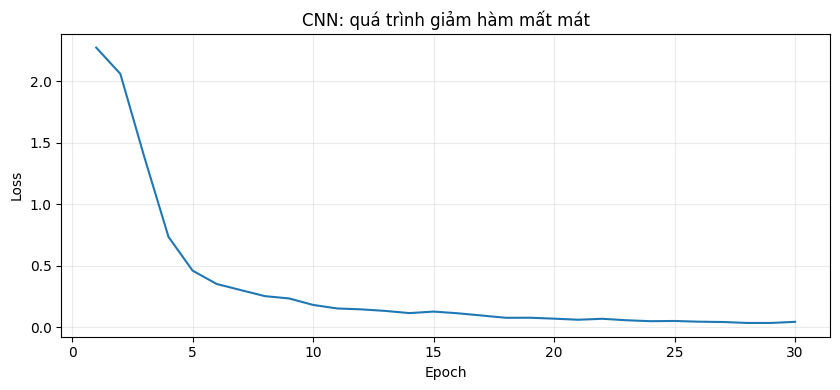

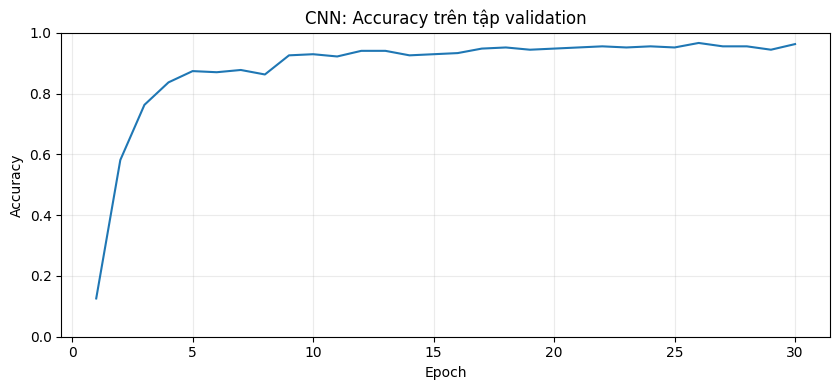

In [7]:
hist_df = pd.DataFrame(history)
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.plot(hist_df['Epoch'], hist_df['Train Loss'], label='Train CrossEntropy')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('CNN: quá trình giảm hàm mất mát')
ax.grid(alpha=.25)
fig.tight_layout()
plt.show()
fig.savefig(OUT / 'chuong3_cnn_loss.png', dpi=160)
plt.close(fig)

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.plot(hist_df['Epoch'], hist_df['Valid Accuracy'], label='Validation Accuracy')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1)
ax.set_title('CNN: Accuracy trên tập validation')
ax.grid(alpha=.25)
fig.tight_layout()
plt.show()
fig.savefig(OUT / 'chuong3_cnn_validation.png', dpi=160)
plt.close(fig)

## Bước 7. Đánh giá lần cuối trên Test

Chỉ **sau khi chọn được mô hình bằng validation** mới tính Accuracy/Macro-F1 trên test. Ma trận nhầm lẫn giúp xem các cặp chữ số dễ lẫn.

In [8]:
model.eval()
with torch.no_grad():
    test_pred = model(teX).argmax(dim=1).numpy()

test_acc = accuracy_score(Y[test_idx], test_pred)
test_f1 = f1_score(Y[test_idx], test_pred, average='macro')
print('Test Accuracy:', f'{test_acc:.4f}', f'({test_acc:.2%})')
print('Test Macro-F1:', f'{test_f1:.4f}')
print('Số tham số:', sum(p.numel() for p in model.parameters()))

Test Accuracy: 0.9667 (96.67%)
Test Macro-F1: 0.9649
Số tham số: 7882


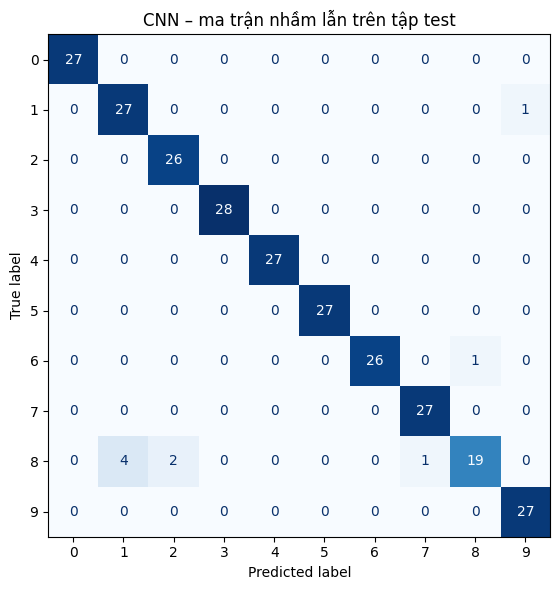

In [9]:
cm = confusion_matrix(Y[test_idx], test_pred, labels=np.arange(10))
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=np.arange(10)).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('CNN – ma trận nhầm lẫn trên tập test')
fig.tight_layout()
plt.show()
fig.savefig(OUT / 'chuong3_cnn_ma_tran_nham_lan.png', dpi=160)
plt.close(fig)

## Bước 8. Lưu kết quả và trọng số mô hình

`.pt` là tệp mô hình PyTorch; CSV lưu lịch sử huấn luyện; JSON chứa chỉ số báo cáo. Mở các ảnh `.png` trong thư mục `ket_qua`.

In [10]:
cnn_result = {
    'seed': SEED,
    'dataset': 'sklearn Digits 8x8',
    'model': '2 Conv2D + 2 MaxPool2D + 2 Dense',
    'params': sum(p.numel() for p in model.parameters()),
    'selected_epoch': best_epoch,
    'best_validation_accuracy': best_val_accuracy,
    'test_accuracy': float(test_acc),
    'test_macro_f1': float(test_f1),
}
with (OUT / 'chuong3_cnn_ket_qua.json').open('w', encoding='utf-8') as f:
    json.dump(cnn_result, f, ensure_ascii=False, indent=2)
hist_df.to_csv(OUT / 'chuong3_cnn_lich_su_huan_luyen.csv', index=False, encoding='utf-8-sig')
torch.save(model.state_dict(), OUT / 'chuong3_cnn_trong_so.pt')
print('Đã lưu tại:', OUT.resolve())

Đã lưu tại: D:\tlHTTM\Bo_code_Jupyter_Tieu_luan_01\ket_qua


## Giải thích khi bảo vệ

- **Vì sao dùng CNN?** Bộ lọc cục bộ có khả năng học nét/biên và dùng chung trọng số tại nhiều vị trí của ảnh.
- **Vì sao đầu ra là 10?** 10 lớp tương ứng các chữ số 0 đến 9.
- **Tại sao không dùng Softmax trong `forward()`?** `CrossEntropyLoss` đã kết hợp tính toán log-softmax theo cách ổn định số.
- **Độ chính xác không bằng 100%?** Tập dữ liệu nhỏ và có các ảnh chữ viết tương tự nhau; mô hình không thể luôn phân biệt hoàn hảo.